In [ ]:
from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import WebBaseLoader
from langchain_openai import OpenAIEmbeddings
# from langchain_core import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import ChatOpenAI


from langgraph.graph import StateGraph , START , END
from typing_extensions import Annotated, TypedDict, Literal
from pydantic import BaseModel, Field
import os
from dotenv import load_dotenv
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_core.documents import Document
from langgraph.prebuilt import ToolNode, tools_condition

from langchain.tools import tool

from langchain_community.utilities import WikipediaAPIWrapper
from langchain_community.tools import WikipediaQueryRun

load_dotenv()

True

In [21]:
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
    )

model = ChatOpenAI(model="gpt-4o-mini", temperature=0)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3418.58it/s]


In [22]:
model.invoke("My name is MAnan what your name")

AIMessage(content="Hello, MAnan! I'm an AI language model and don't have a personal name, but you can call me Assistant. How can I help you today?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 32, 'prompt_tokens': 16, 'total_tokens': 48, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_3ef558a83f', 'id': 'chatcmpl-DeG3ydTyr31sh7nSjC3LJLsjJQjN8', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e1619-9726-7480-8b25-646e26153b62-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 16, 'output_tokens': 32, 'total_tokens': 48, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

## Database Connection

In [57]:
from langchain_astradb import AstraDBVectorStore
import os
vectorstore = AstraDBVectorStore(
    embedding=embeddings,
    collection_name="AI_Legal_database",
    api_endpoint=os.getenv("ASTRA_DB_API_ENDPOINT"),
    token=os.getenv("ASTRA_DB_APPLICATION_TOKEN"),
    namespace=None,
    autodetect_collection=True,
)
retriever = vectorstore.as_retriever()

c:\Users\soodm\Desktop\langraph_practice\.venv\Lib\site-packages\langchain_astradb\vectorstores.py:1067: UserWarning: Collection supports lexical; however, autodetect found documents without a $lexical. The $lexical field will be set for new documents, but the pre-existing documents might not be reached by lexical search when running hybrid search mode.
  self.document_codec = _detect_document_codec(


In [32]:
retriever.invoke("What do you mean by land acquisition act ?")

[Document(id='706e27d5236942b3a2ebf6f57e0da32e', metadata={'producer': 'htmldoc 1.9.15 Copyright 2011-2022 by Michael R Sweet', 'creator': 'PyPDF', 'creationdate': '2025-04-05T20:07:21+00:00', 'title': 'Kolkata Municipal Corporation vs Bimal Kumar Shah on 16 May, 2024', 'source': 'supreme_court_judgments\\2024\\Kolkata_Municipal_Corporation_vs_Bimal_Kumar_Shah_on_16_May_2024_1.PDF', 'total_pages': 16, 'page': 9, 'page_label': '10'}, page_content='iii In a large number of decisions our constitutional courts have independently recognised the right to notice before any process of acquisition is commenced The Right to be heard i Following the right to a meaningful and effective prior notice of acquisition is the right of the property bearer to communicate his objections and concerns to the authority acquiring the property This right to be heard against the proposed acquisition must be meaningful and not a sham ii Section A of the Land Acquisition Act Section of the Requisitioning and Acqui

In [39]:
class RAG(BaseModel):
    question: str = Field(default="What is an AI agent?")
    answer: str = ""
    retrieved_docs: list[Document] = []

In [67]:

@tool("wikipedia_search")
def wikipedia_search(query):
    """Use this tool to get a summary of information from Wikipedia if you didn't get enough information."""
    print("Wikipedia Search Tool Called with query:", query)
    wiki = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(doc_content_chars_max=1000, top_k_results=1))
    return wiki.invoke(query)


tool_node = ToolNode([wikipedia_search])

In [48]:
tools = [wikipedia_search]
model_tools = model.bind_tools(tools)

In [72]:
tools = [wikipedia_search]
model_tools = model.bind_tools(tools)   # only used in retriever

def retriever_document(state: RAG) -> RAG:
    question = state.question
    docs = retriever.invoke(question)
    # LLM with tools decides if Wikipedia is needed
    ai_response = model_tools.invoke(question)
    return RAG(question=question, retrieved_docs=docs, answer=ai_response.content)

def generate_answer(state: RAG) -> RAG:
    context = "\n".join([doc.page_content for doc in state.retrieved_docs])
    prompt = f"""Answer the question based on the context below.
    
Context:
{context}

Question: {state.question}
Answer:"""
    # plain model — no tools, no routing
    answer = model.invoke(prompt)
    return RAG(question=state.question, retrieved_docs=state.retrieved_docs, answer=answer.content)


In [73]:
graph = StateGraph(RAG)

graph.add_node("retriever", retriever_document)
graph.add_node("generator", generate_answer)
graph.add_node("tools", tool_node)

graph.add_edge(START, "retriever")

# ✅ Condition on retriever (where tool-bound LLM runs)
graph.add_conditional_edges(
    "retriever",
    tools_condition,
    {
        "tools":  "tools",
        "__end__": "generator"   
    }
)

graph.add_edge("tools", "generator")   
graph.add_edge("generator", END)

result = graph.compile()

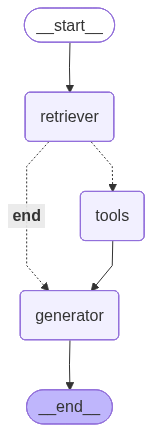

In [74]:
result

In [75]:
result = result.invoke({"question": "Give me idea about Arvind Kejriwal's case?"})

ValueError: No messages found in input state to tool_edge: question="Give me idea about Arvind Kejriwal's case?" answer='' retrieved_docs=[Document(id='8714de08cdbd4ad0bd1c1b0350eaf486', metadata={'producer': 'htmldoc 1.9.15 Copyright 2011-2022 by Michael R Sweet', 'creator': 'PyPDF', 'creationdate': '2025-04-05T20:15:18+00:00', 'title': 'Arvind Kejriwal vs Central Bureau Of Investigation on 13 September, 2024', 'source': 'supreme_court_judgments\\2024\\Arvind_Kejriwal_vs_Central_Bureau_Of_Investigation_on_13_September_2024_1.PDF', 'total_pages': 26, 'page': 0, 'page_label': '1'}, page_content='Arvind Kejriwal vs Central Bureau Of Investigation on September Author Surya Kant Bench Surya Kant INSC REPORTABLE IN THE SUPREME COURT OF INDIA CRIMINAL APPELLATE JURISDICTION Criminal Appeal No Arising out of Special Leave Petition Crl No Arvind Kejriwal Appellant s versus Central Bureau of Investigation Respondent s WITH Criminal Appeal No Arising out of Special Leave Petition Crl No JUDGEMEN

In [ ]:
result.answer

"Arvind Kejriwal, the Chief Minister of Delhi, is involved in multiple legal cases concerning his arrests by different investigative agencies, namely the Central Bureau of Investigation (CBI) and the Directorate of Enforcement (DoE). \n\n1. **Case Against CBI**: In one case, Kejriwal challenged his arrest by the CBI, arguing that it was illegal. The High Court of Delhi dismissed his challenge and upheld the legality of his arrest, also denying his application for regular bail. This case revolves around the legality of his arrest and the subsequent denial of bail.\n\n2. **Case Against DoE**: In another case, Kejriwal contested his arrest by the DoE under the Prevention of Money Laundering Act. He filed a writ petition challenging the validity of his arrest, which was also rejected by the High Court. This case raises significant legal questions regarding the scope of the trial court's authority to examine the legality of arrests under the relevant sections of the law.\n\nIn both instance

In [ ]:
from IPython.display import Markdown, display

display(Markdown(f"### Answer\n\n{result.answer}"))

### Answer

Arvind Kejriwal, the Chief Minister of Delhi, is involved in multiple legal cases concerning his arrests by different investigative agencies, namely the Central Bureau of Investigation (CBI) and the Directorate of Enforcement (DoE). 

1. **Case Against CBI**: In one case, Kejriwal challenged his arrest by the CBI, arguing that it was illegal. The High Court of Delhi dismissed his challenge and upheld the legality of his arrest, also denying his application for regular bail. This case revolves around the legality of his arrest and the subsequent denial of bail.

2. **Case Against DoE**: In another case, Kejriwal contested his arrest by the DoE under the Prevention of Money Laundering Act. He filed a writ petition challenging the validity of his arrest, which was also rejected by the High Court. This case raises significant legal questions regarding the scope of the trial court's authority to examine the legality of arrests under the relevant sections of the law.

In both instances, Kejriwal's legal team has raised various legal issues, including the violation of his rights and the legitimacy of the arrests. The courts have considered factors such as his status as a public figure, the seriousness of the accusations, and the ongoing investigations. The proceedings are complex and involve significant legal arguments, with the Supreme Court yet to make final determinations on the legality of the arrests.

In [ ]:
for i in range(len(result.retrieved_docs)):
    display(Markdown(f"### Retrieved Document {i+1}\n\n{result.retrieved_docs[i].metadata['source']}"))

### Retrieved Document 1

supreme_court_judgments\2024\Arvind_Kejriwal_vs_Central_Bureau_Of_Investigation_on_13_September_2024_1.PDF

### Retrieved Document 2

supreme_court_judgments\2024\Arvind_Kejriwal_vs_Directorate_Of_Enforcement_on_12_July_2024_1.PDF

### Retrieved Document 3

supreme_court_judgments\2024\Arvind_Kejriwal_vs_Directorate_Of_Enforcement_on_10_May_2024_1.PDF

### Retrieved Document 4

supreme_court_judgments\2024\Arvind_Kejriwal_vs_Directorate_Of_Enforcement_on_10_May_2024_1.PDF

In [ ]:
from langchain_tavily import TavilySearch
from langchain.tools import tool

os.getenv("TAVILY_API_KEY")
# @tool("websearch")
def websearch(query):
    """Use this tool to search the web for the latest information on a topic."""
    print("Web Search Tool Called with query:", query)
    tool = TavilySearch(
        max_results=5,
        topic='general',
    )
    
    return tool.invoke({'query': query})

In [ ]:
result = websearch("What are the latest news about America?")

Web Search Tool Called with query: What are the latest news about America?


ValidationError: 1 validation error for TavilySearchAPIWrapper
  Value error, Did not find tavily_api_key, please add an environment variable `TAVILY_API_KEY` which contains it, or pass `tavily_api_key` as a named parameter. [type=value_error, input_value={}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.13/v/value_error